In [1]:
import pandas as pd 
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt 
from sklearn.model_selection import GridSearchCV , train_test_split
from sklearn.metrics import r2_score 
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder , LabelEncoder , StandardScaler

In [2]:
df = pd.read_csv("HousePricePrediction.csv")

In [3]:
df.isnull().sum()

Id                 0
MSSubClass         0
MSZoning           4
LotArea            0
LotConfig          0
BldgType           0
OverallCond        0
YearBuilt          0
YearRemodAdd       0
Exterior1st        1
BsmtFinSF2         1
TotalBsmtSF        1
SalePrice       1459
dtype: int64

# Dropping Null SalePrice 

In [41]:
df=df.dropna()

In [42]:
df2

array([[0., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(1460, 4275))

In [44]:
df.isnull().sum()

Id              0
MSSubClass      0
MSZoning        0
LotArea         0
LotConfig       0
BldgType        0
OverallCond     0
YearBuilt       0
YearRemodAdd    0
Exterior1st     0
BsmtFinSF2      0
TotalBsmtSF     0
SalePrice       0
dtype: int64

In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1460 entries, 0 to 1459
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Id            1460 non-null   int64  
 1   MSSubClass    1460 non-null   int64  
 2   MSZoning      1460 non-null   object 
 3   LotArea       1460 non-null   int64  
 4   LotConfig     1460 non-null   object 
 5   BldgType      1460 non-null   object 
 6   OverallCond   1460 non-null   int64  
 7   YearBuilt     1460 non-null   int64  
 8   YearRemodAdd  1460 non-null   int64  
 9   Exterior1st   1460 non-null   object 
 10  BsmtFinSF2    1460 non-null   float64
 11  TotalBsmtSF   1460 non-null   float64
 12  SalePrice     1460 non-null   float64
dtypes: float64(3), int64(6), object(4)
memory usage: 159.7+ KB


In [47]:
obj_col=df.select_dtypes("object").columns

In [48]:
obj_col

Index(['MSZoning', 'LotConfig', 'BldgType', 'Exterior1st'], dtype='object')

In [49]:
num_col=df.select_dtypes("number").columns

In [50]:
num_col

Index(['Id', 'MSSubClass', 'LotArea', 'OverallCond', 'YearBuilt',
       'YearRemodAdd', 'BsmtFinSF2', 'TotalBsmtSF', 'SalePrice'],
      dtype='object')

# EDA

<Axes: xlabel='SalePrice', ylabel='Count'>

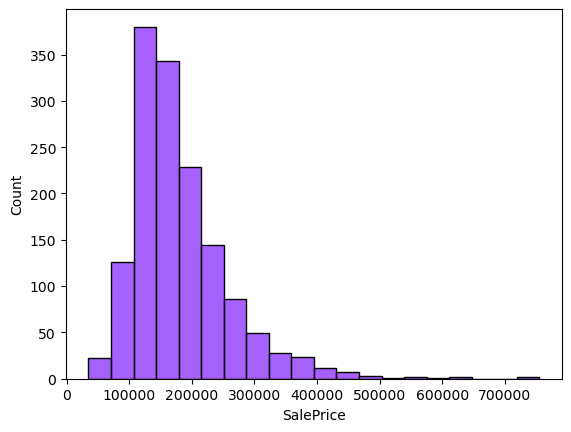

In [52]:
sns.histplot(
    data=df,
    x="SalePrice",
    bins=20,
    color="#892bfb"
    
)

In [53]:
value_count = df["MSZoning"].value_counts()

In [54]:
value_count

MSZoning
RL         1151
RM          218
FV           65
RH           16
C (all)      10
Name: count, dtype: int64

<Axes: xlabel='MSZoning', ylabel='count'>

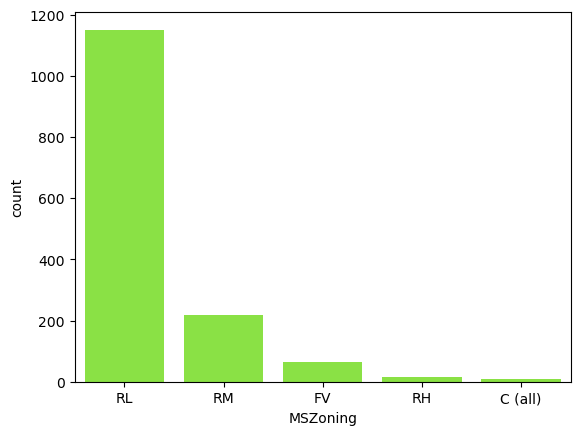

In [55]:
sns.barplot(
    data=value_count,
    color="#87fb2b"
)

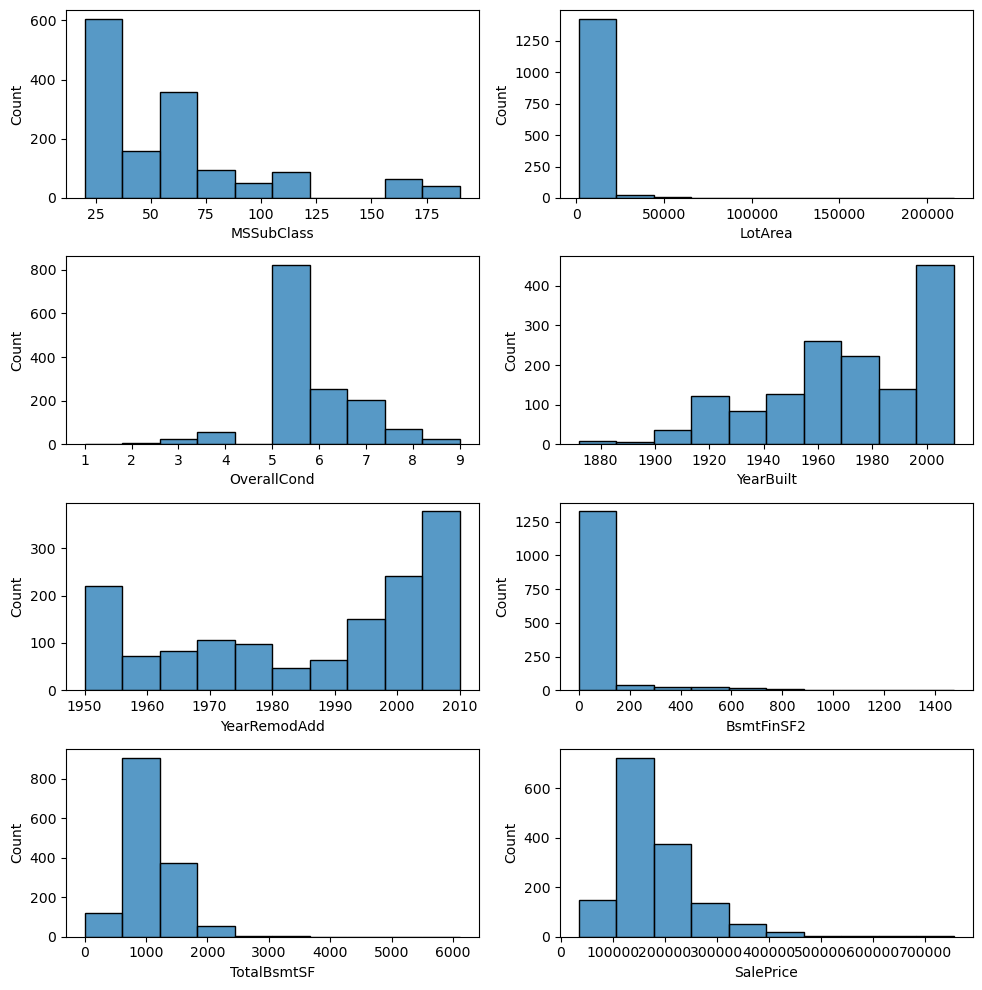

In [56]:
fig, axes = plt.subplots(4,2, figsize=(10,10))
col=1
for i in range(4):
    for j in range(2):
        sns.histplot(
            ax=axes[i,j],
            data=df,
            x=num_col[col],
            bins=10
        )
        col+=1
fig.tight_layout()

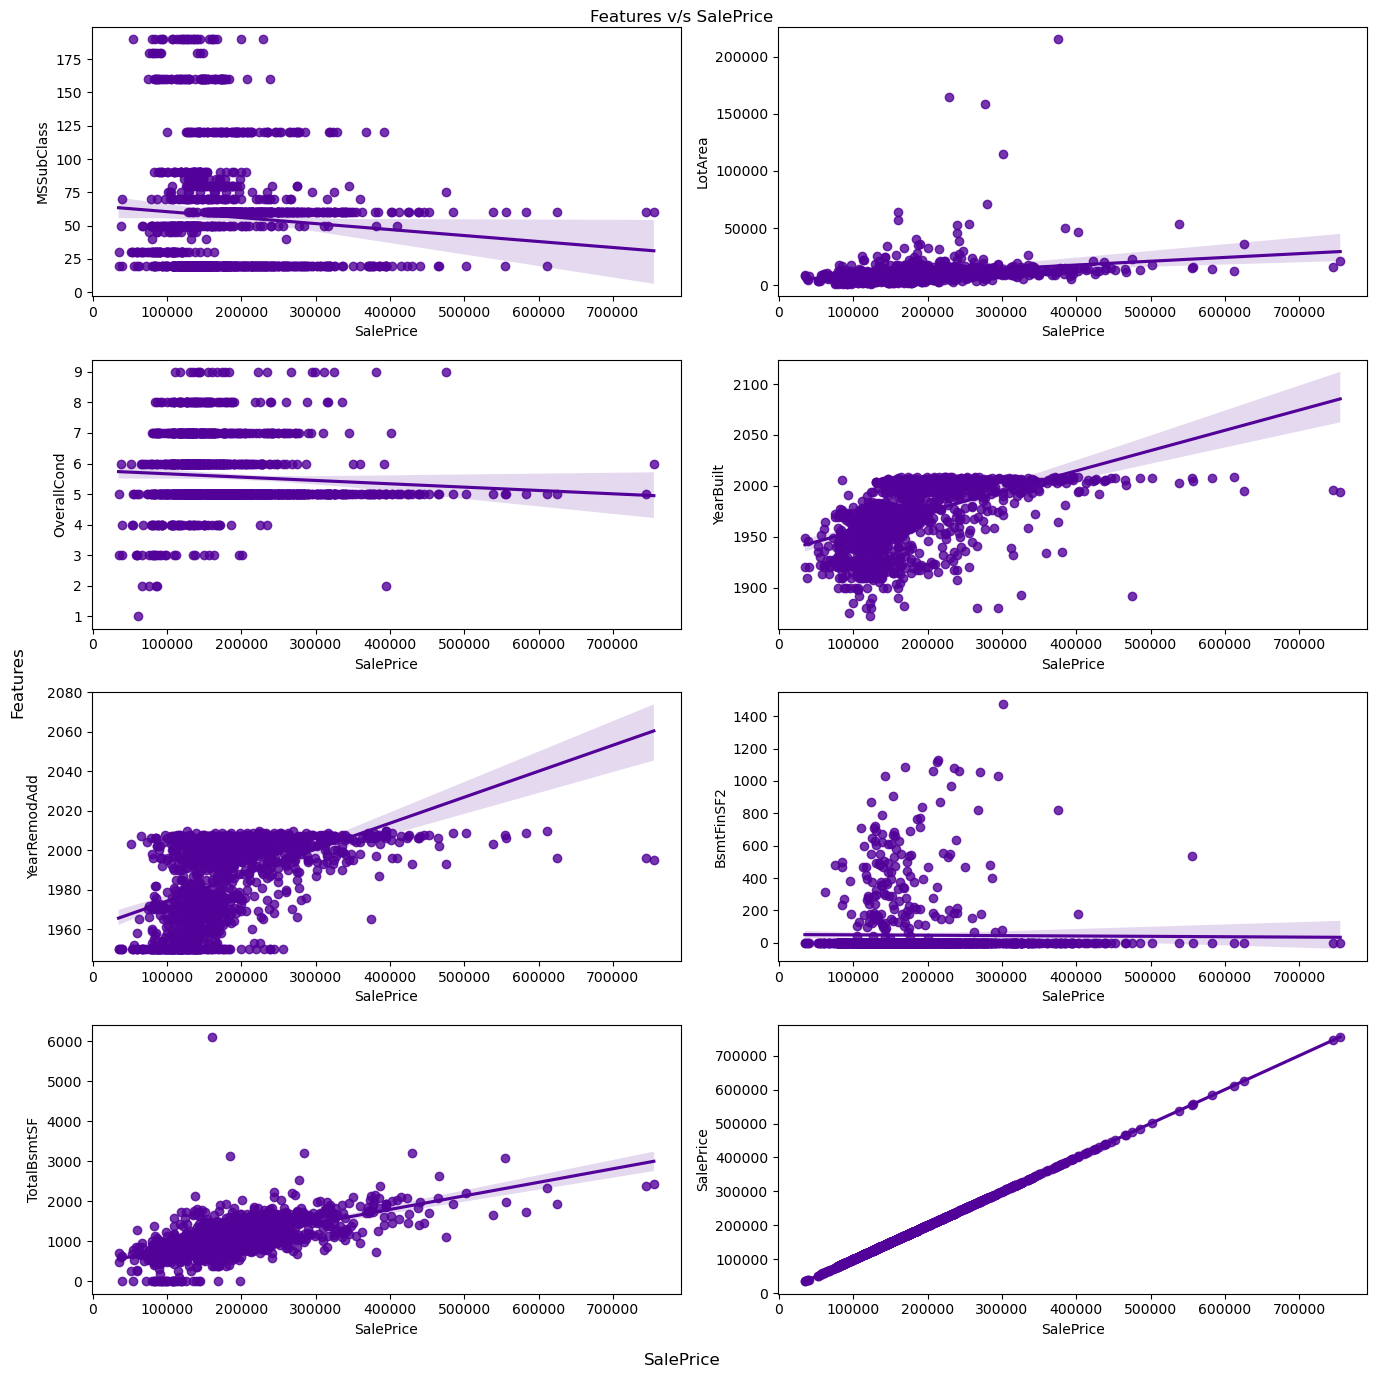

In [114]:
fig, axes = plt.subplots(4,2, figsize=(14,14))
col=1
for i in range(4):
    for j in range(2):
        sns.regplot(
            ax=axes[i,j],
            data=df,
            x="SalePrice",
            y=num_col[col],
            color="#530299",
            ci=100
        )
        col+=1
fig.suptitle("Features v/s SalePrice")
fig.supxlabel("SalePrice")
fig.supylabel("Features")
fig.tight_layout()


In [57]:
df.sample(3)

,Id,MSSubClass,MSZoning,LotArea,LotConfig,BldgType,OverallCond,YearBuilt,YearRemodAdd,Exterior1st,BsmtFinSF2,TotalBsmtSF,SalePrice
261,261,60,RL,9588,Inside,1Fam,5,2007,2007,CemntBd,0.0,1482.0,276000.0
1324,1324,20,RL,9986,Inside,1Fam,5,2006,2007,VinylSd,0.0,1795.0,147000.0
716,716,70,RM,10800,Inside,1Fam,8,1890,1998,Wd Sdng,0.0,718.0,159500.0


# Encoding 

In [58]:
df["Exterior1st"].unique()

array(['VinylSd', 'MetalSd', 'Wd Sdng', 'HdBoard', 'BrkFace', 'WdShing',
       'CemntBd', 'Plywood', 'AsbShng', 'Stucco', 'BrkComm', 'AsphShn',
       'Stone', 'ImStucc', 'CBlock'], dtype=object)

In [59]:
df["BldgType"].unique()

array(['1Fam', '2fmCon', 'Duplex', 'TwnhsE', 'Twnhs'], dtype=object)

In [60]:
df["LotConfig"].unique()

array(['Inside', 'FR2', 'Corner', 'CulDSac', 'FR3'], dtype=object)

In [62]:
ohe=OneHotEncoder(drop="first",sparse_output=False,handle_unknown="ignore")
values= ohe.fit_transform(df[obj_col])

In [67]:
df2 = pd.DataFrame(values , columns=ohe.get_feature_names_out(obj_col))

In [71]:
df = pd.concat([df.drop(columns=obj_col),df2 ],axis=1)

# Feature Selection 

In [73]:
X = df.drop(columns=["Id","SalePrice"])
y=df["SalePrice"]

In [76]:
X_train,X_test,Y_train,Y_test = train_test_split(
    X,y,random_state=42,test_size=0.3
)

# Scaling 

In [78]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# LinearRegression

In [139]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()

model.fit(X_train_scaled , Y_train)
Y_pred = model.predict(X_test_scaled)
Y_tpred = model.predict(X_train_scaled)

# accuracy r2_score 
lr_test = r2_score(Y_test,Y_pred)
lr_train = r2_score(Y_train,Y_tpred)

print(f'testing accuracy : {lr_test}')
print(f'training accuracy : {lr_train}')


testing accuracy : 0.6294462899245679
training accuracy : 0.6057540953154135


# DecisionTree Regression

In [122]:
from sklearn.tree import DecisionTreeRegressor

pipe= Pipeline([
    ("scaler",StandardScaler()),
    ("dtr",DecisionTreeRegressor())
])
param = {
    "dtr__max_depth":[6,7,8,9],
    "dtr__min_samples_leaf":[2,3,4,5],
    "dtr__min_samples_split":[2,3,4,5]
}
model = GridSearchCV(
    estimator=pipe,
    param_grid=param,
    cv=5
)
model.fit(X_train , Y_train)
Y_pred = model.predict(X_test)
Y_tpred = model.predict(X_train)

# accuracy r2_score 
dt_test = r2_score(Y_test,Y_pred)
dt_train = r2_score(Y_train,Y_tpred)

print(f'testing accuracy : {dt_test}')
print(f'training accuracy : {dt_train}')

print(f'best model \n  {model.best_params_}')

testing accuracy : 0.7405062047404134
training accuracy : 0.9071980503779349
best model 
  {'dtr__max_depth': 9, 'dtr__min_samples_leaf': 3, 'dtr__min_samples_split': 5}


# RandomForest Regressor

In [226]:
from sklearn.ensemble import RandomForestRegressor

pipe= Pipeline([
    ("scaler",StandardScaler()),
    ("rfr",RandomForestRegressor(max_depth=8,min_samples_leaf=3,min_samples_split=2))
])
param = {
    "rfr__n_estimators":[100],
}
model = GridSearchCV(
    estimator=pipe,
    param_grid=param,
    cv=5
)
model.fit(X_train , Y_train)
Y_pred = model.predict(X_test)
Y_tpred = model.predict(X_train)

# accuracy r2_score 
rf_test = r2_score(Y_test,Y_pred)
rf_train = r2_score(Y_train,Y_tpred)

print(f'testing accuracy : {rf_test}')
print(f'training accuracy : {rf_train}')

print(f'best model \n  {model.best_params_}')

testing accuracy : 0.830499914636587
training accuracy : 0.8853230980516001
best model 
  {'rfr__n_estimators': 100}


# SupportVectorRegressor

In [124]:
from sklearn.svm import SVR
pipe= Pipeline([
    ("scaler",StandardScaler()),
    ("svr",SVR())
])
param = {
    "svr__C":[1,2],
    "svr__kernel":["rbf","poly","linear","sigmoid"],
    "svr__epsilon":[0.01,0.1,1],
    "svr__degree":[1,2]
}
model = GridSearchCV(
    estimator=pipe,
    param_grid=param,
    cv=5
)
model.fit(X_train , Y_train)
Y_pred = model.predict(X_test)
Y_tpred = model.predict(X_train)

# accuracy r2_score 
svm_test = r2_score(Y_test,Y_pred)
svm_train = r2_score(Y_train,Y_tpred)

print(f'testing accuracy : {svm_test}')
print(f'training accuracy : {svm_train}')

print(f'best model \n  {model.best_params_}')

testing accuracy : 0.02762396545742385
training accuracy : 0.023307715774323112
best model 
  {'svr__C': 2, 'svr__degree': 1, 'svr__epsilon': 1, 'svr__kernel': 'linear'}


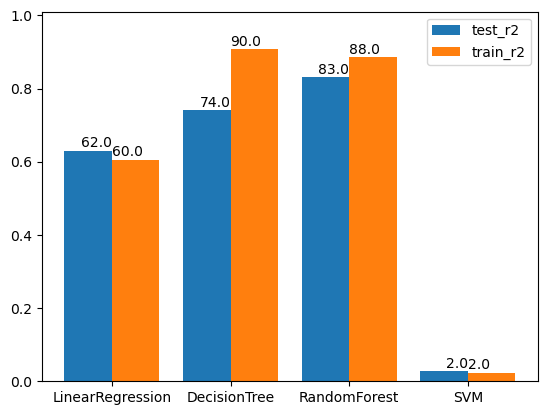

In [232]:
test_r2=[lr_test,dt_test,rf_test,svm_test]
train_r2=[lr_train,dt_train,rf_train,svm_train]
name=["LinearRegression","DecisionTree","RandomForest","SVM"]
x=np.array([1,2,3,4])
width=0.40
plt.bar(x-width/2,test_r2,width ,label="test_r2")
plt.bar(x+width/2 ,train_r2,width , label="train_r2")
plt.xticks(x,name)
plt.legend()
plt.ylim(0,1+0.01)

for i in range(len(x)):
    plt.text(x[i] ,test_r2[i]+0.01 , str(test_r2[i]*100//1) , ha="right")
    plt.text(x[i] ,train_r2[i]+0.01 , str(train_r2[i]*100//1) , ha="left")

plt.savefig("HousePricePredictorModel.png")

# Optimize Model --> RandomForestRegressor

In [229]:
output=[Y_test , Y_pred]
d1=pd.DataFrame(Y_test,columns=["Y_test"])
d2=pd.DataFrame(Y_pred,columns=["Y_pred"])

output_df = pd.concat([d1,d2],axis=1)

In [231]:
output_df.head(20)

,Y_test,Y_pred
0,154500.0,155189.249114
1,325000.0,276886.205152
2,115000.0,130392.254887
3,159000.0,127482.881230
4,315500.0,277009.210916
5,75500.0,98311.163394
6,311500.0,281358.864245
7,146000.0,140340.782785
8,84500.0,98554.821312
9,135500.0,162666.166809
